In [83]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns


In [118]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.7 MB/s eta 0:00:00


In [84]:
DATA_DIR = "/content/hotel_bookings.csv"

In [85]:
df = pd.read_csv(DATA_DIR)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [86]:
import seaborn as sns
import matplotlib.pyplot as plt





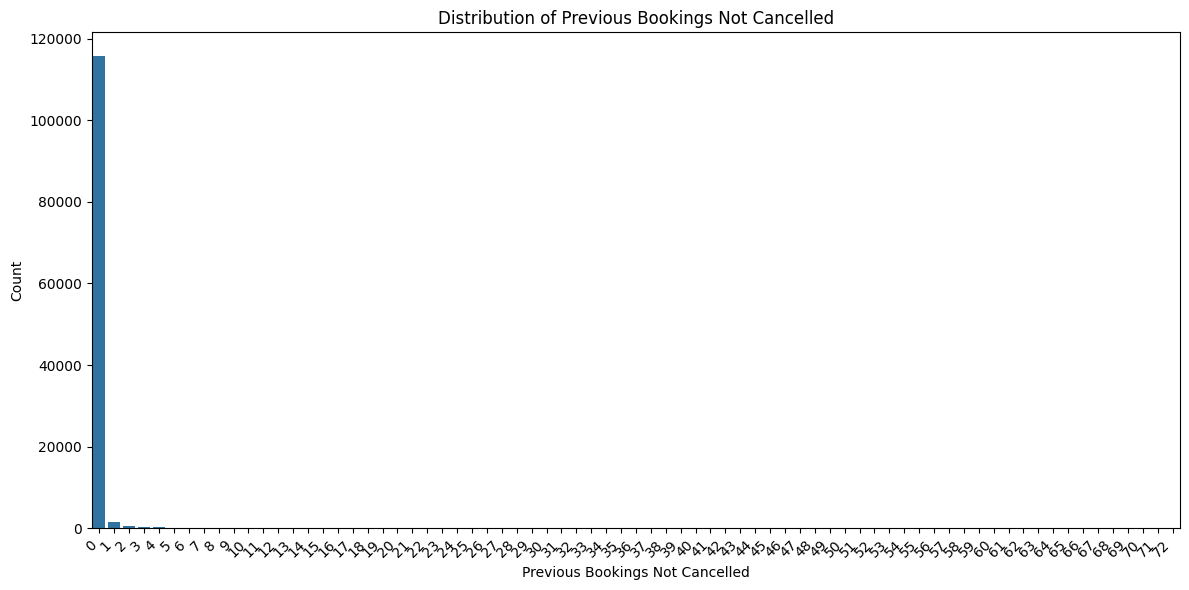

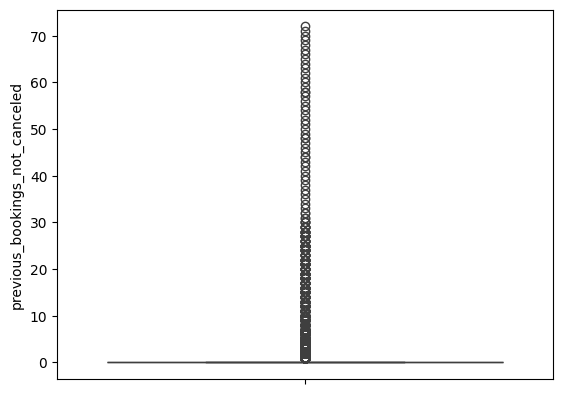

In [87]:
# Plot for PreviousBookingsNotCancelled
plt.figure(figsize=(12, 6)) # Increased figure size
sns.countplot(data = df, x = 'previous_bookings_not_canceled', order=sorted(df['previous_bookings_not_canceled'].unique())) # Order bars numerically
plt.title('Distribution of Previous Bookings Not Cancelled')
plt.xlabel('Previous Bookings Not Cancelled')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
plt.tight_layout() # Adjust layout
plt.show()

sns.boxplot(data = df, y = 'previous_bookings_not_canceled')
plt.show()

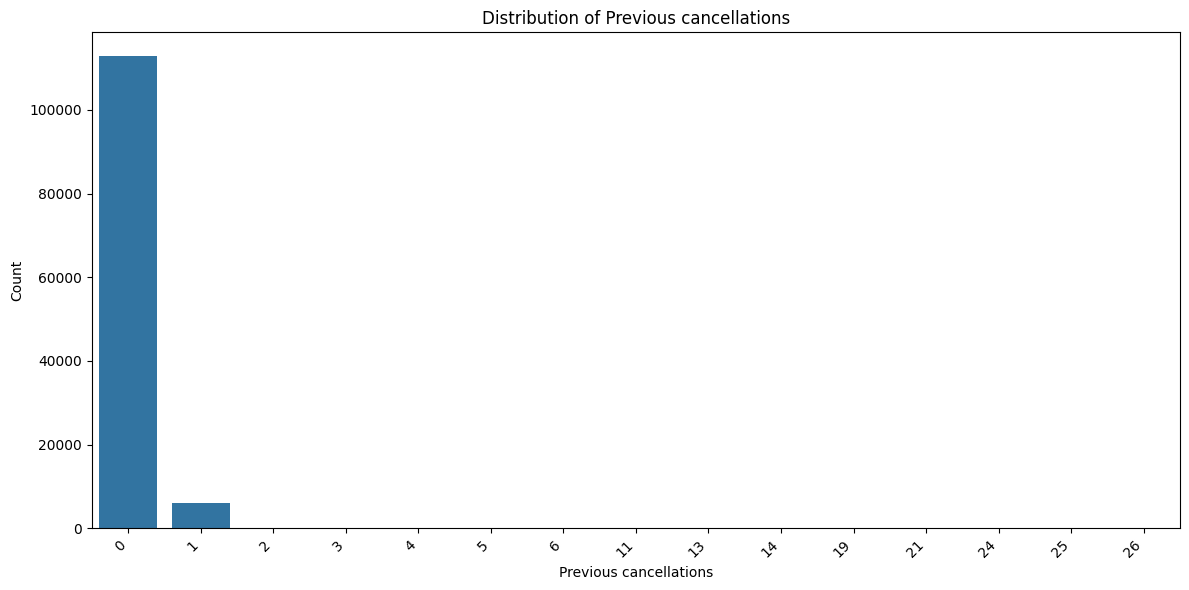

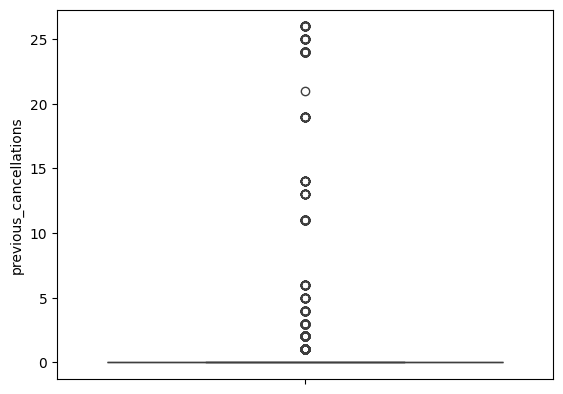

In [88]:
# Plot for PreviousCancellations
plt.figure(figsize=(12, 6)) # Increased figure size
sns.countplot(data = df, x = 'previous_cancellations', order=sorted(df['previous_cancellations'].unique())) # Order bars numerically
plt.title('Distribution of Previous cancellations')
plt.xlabel('Previous cancellations')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels
plt.tight_layout() # Adjust layout
plt.show()

sns.boxplot(data = df, y = 'previous_cancellations')
plt.show()

In [89]:
print(df.shape)
print(len(df[df['is_canceled' ]==0]))

(119390, 32)
75166


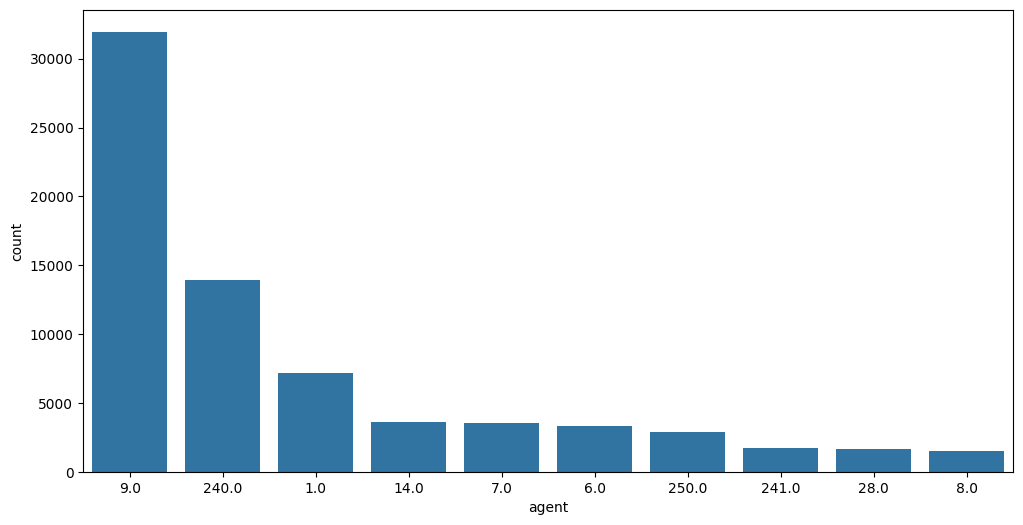

In [90]:
# boxplot for the count of travel agents
top_agents = df['agent'].value_counts().head(10).index
plt.figure(figsize=(12, 6))
sns.countplot(data = df, x = 'agent', order = top_agents)
plt.show()

In [91]:
print('Descriptive statistics for potential outlier columns:')
columns_to_check = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'required_car_parking_spaces', 'total_of_special_requests', 'previous_cancellations', 'previous_bookings_not_canceled']

for col in columns_to_check:
    print(f'\n--- {col} ---')
    print(df[col].describe())

Descriptive statistics for potential outlier columns:

--- lead_time ---
count    119390.000000
mean        104.011416
std         106.863097
min           0.000000
25%          18.000000
50%          69.000000
75%         160.000000
max         737.000000
Name: lead_time, dtype: float64

--- stays_in_weekend_nights ---
count    119390.000000
mean          0.927599
std           0.998613
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          19.000000
Name: stays_in_weekend_nights, dtype: float64

--- stays_in_week_nights ---
count    119390.000000
mean          2.500302
std           1.908286
min           0.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          50.000000
Name: stays_in_week_nights, dtype: float64

--- adults ---
count    119390.000000
mean          1.856403
std           0.579261
min           0.000000
25%           2.000000
50%           2.000000
75%           2.000000
max          5

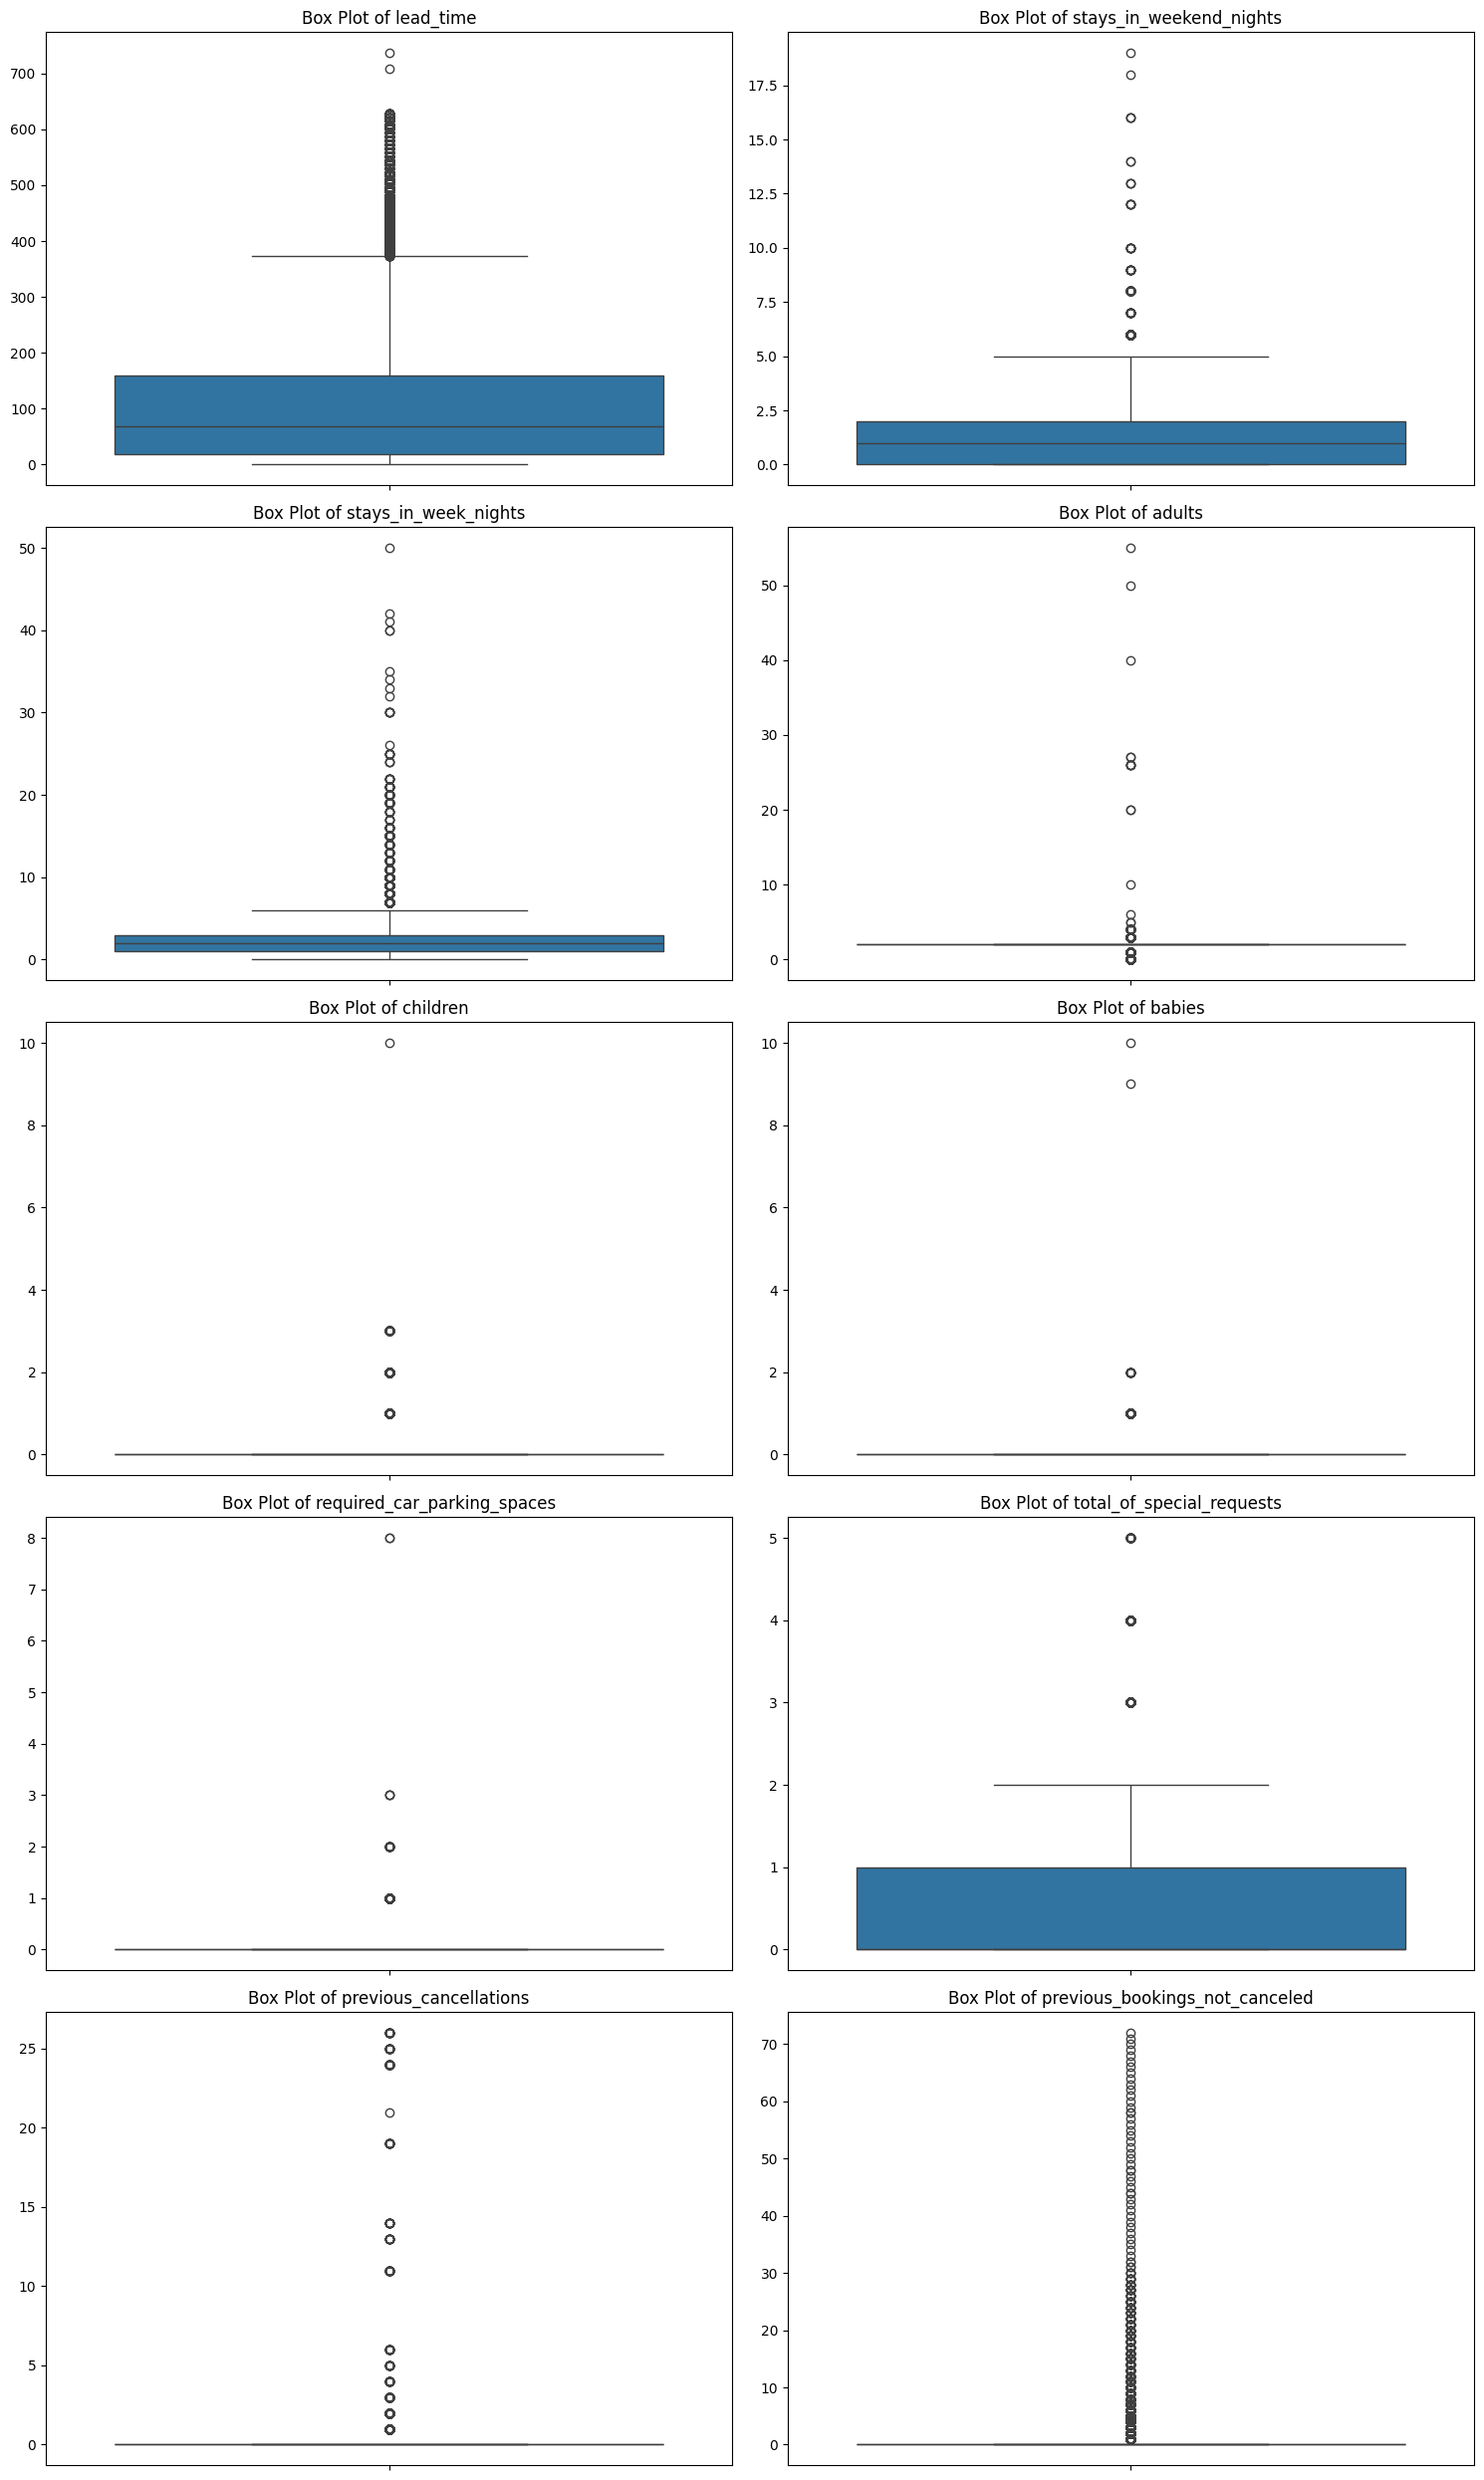

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create box plots for the identified columns
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 25))
axes = axes.flatten()

for i, col in enumerate(columns_to_check):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

In [93]:
df[df['lead_time']>600].head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
4182,Resort Hotel,0,709,2016,February,9,25,8,20,2,...,No Deposit,NaN,NaN,0,Transient,68.0,0,0,Check-Out,2016-03-24
58879,City Hotel,1,605,2016,October,43,17,1,2,2,...,Non Refund,1.0,NaN,0,Transient,60.0,0,0,Canceled,2016-09-20
58880,City Hotel,1,605,2016,October,43,17,1,2,2,...,Non Refund,1.0,NaN,0,Transient,60.0,0,0,Canceled,2016-09-20
58883,City Hotel,1,605,2016,October,43,17,1,2,2,...,Non Refund,1.0,NaN,0,Transient,60.0,0,0,Canceled,2016-09-20


In [94]:
df[df['stays_in_weekend_nights']>15].head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
9839,Resort Hotel,1,322,2017,January,2,10,16,40,2,...,No Deposit,8.0,NaN,0,Transient,25.50,0,0,Canceled,2016-10-31
14037,Resort Hotel,0,113,2015,August,31,1,18,42,1,...,No Deposit,NaN,NaN,0,Transient,110.50,0,3,Check-Out,2015-09-30
14038,Resort Hotel,0,126,2016,July,28,5,19,50,1,...,No Deposit,NaN,NaN,0,Transient,110.00,0,3,Check-Out,2016-09-12
33924,Resort Hotel,0,71,2017,January,2,10,16,40,2,...,No Deposit,196.0,NaN,0,Transient,28.79,0,0,Check-Out,2017-03-07
101794,City Hotel,0,140,2016,September,39,22,16,41,0,...,No Deposit,9.0,NaN,0,Transient,8.34,0,2,Check-Out,2016-11-18


In [95]:

df[df['stays_in_week_nights']>40].head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14037,Resort Hotel,0,113,2015,August,31,1,18,42,1,...,No Deposit,NaN,NaN,0,Transient,110.50,0,3,Check-Out,2015-09-30
14038,Resort Hotel,0,126,2016,July,28,5,19,50,1,...,No Deposit,NaN,NaN,0,Transient,110.00,0,3,Check-Out,2016-09-12
101794,City Hotel,0,140,2016,September,39,22,16,41,0,...,No Deposit,9.0,NaN,0,Transient,8.34,0,2,Check-Out,2016-11-18


In [96]:
df[df['adults']>30].head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
1539,Resort Hotel,1,304,2015,September,36,3,0,3,40,...,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-02
1643,Resort Hotel,1,336,2015,September,37,7,1,2,50,...,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-18
2173,Resort Hotel,1,338,2015,October,41,4,2,0,55,...,No Deposit,NaN,NaN,0,Group,0.0,0,0,Canceled,2015-01-02


In [97]:
df[df['adults'] == 0].head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,No Deposit,NaN,174.0,0,Transient-Party,0.0,0,0,Check-Out,2015-10-06
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,No Deposit,NaN,174.0,0,Transient,0.0,0,0,Check-Out,2015-10-12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,No Deposit,38.0,NaN,0,Transient-Party,0.0,0,0,Check-Out,2015-11-23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,No Deposit,308.0,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016-01-04
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,No Deposit,308.0,NaN,122,Transient-Party,0.0,0,0,Check-Out,2016-01-05


We clean the data.
1. we will remove all with adr == 0, since that doesn't make sense
2. we will remove adr > 1000, as that is an outlier also.
3. if adults == children == 0, we will remove these data
4. if children == 10 remove
5. if babies >8 remove

In [136]:
df_cleaned = df[(df['adr'] > 0) & (df['adr'] < 1000) & ((df['adults']>0) | (df['children']>0))& (df['children']<10) & (df['babies']<9)]
df_cleaned.shape

(117391, 32)

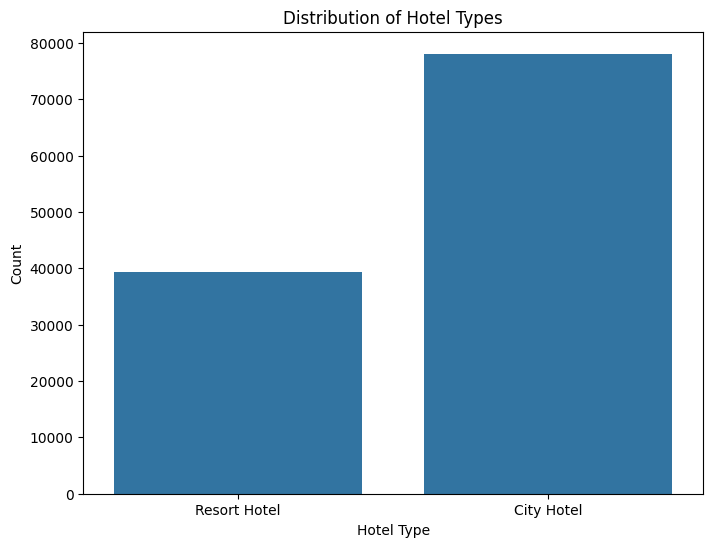

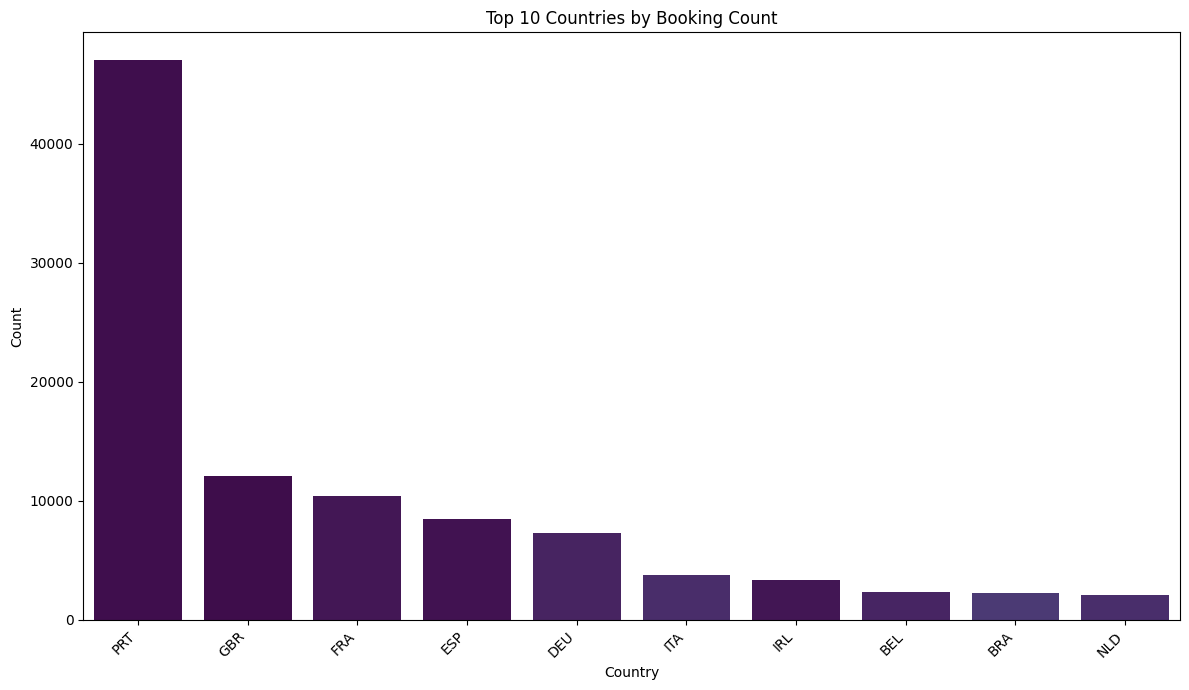

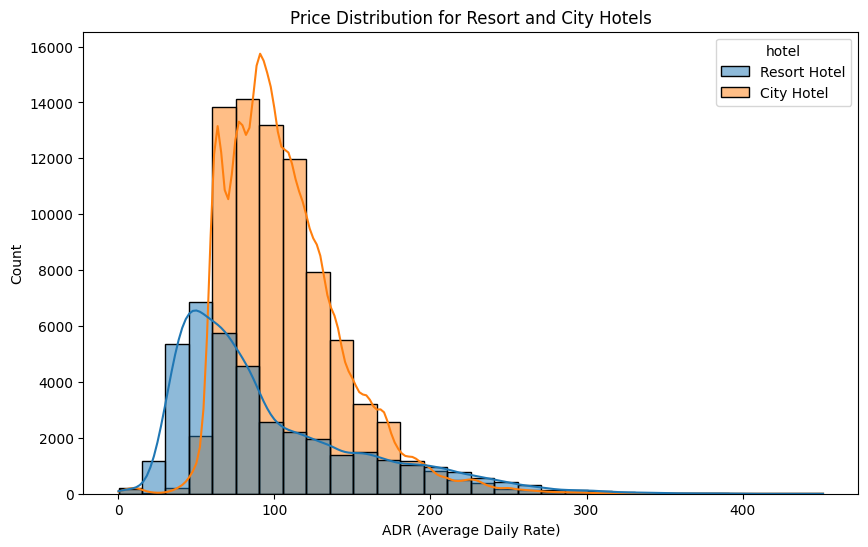

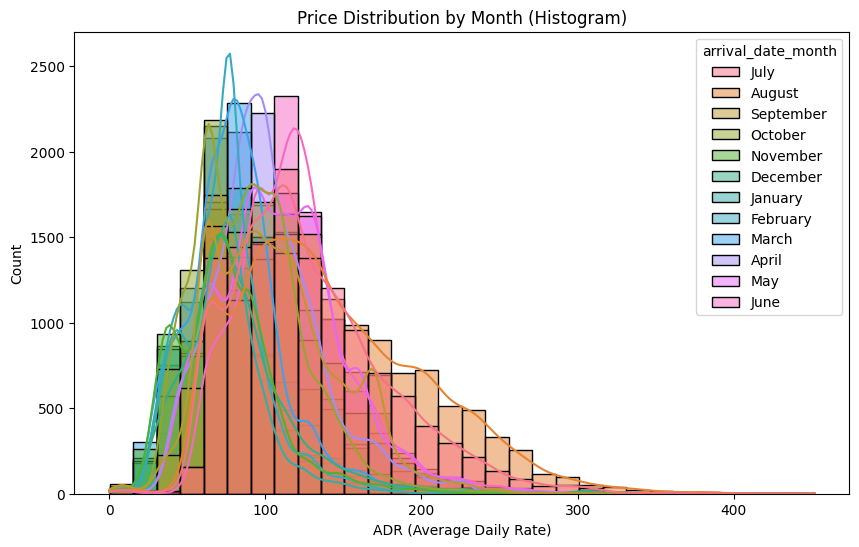

/tmp/ipykernel_11810/2556734130.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df_cleaned, x='arrival_date_month', y='adr', palette='coolwarm')


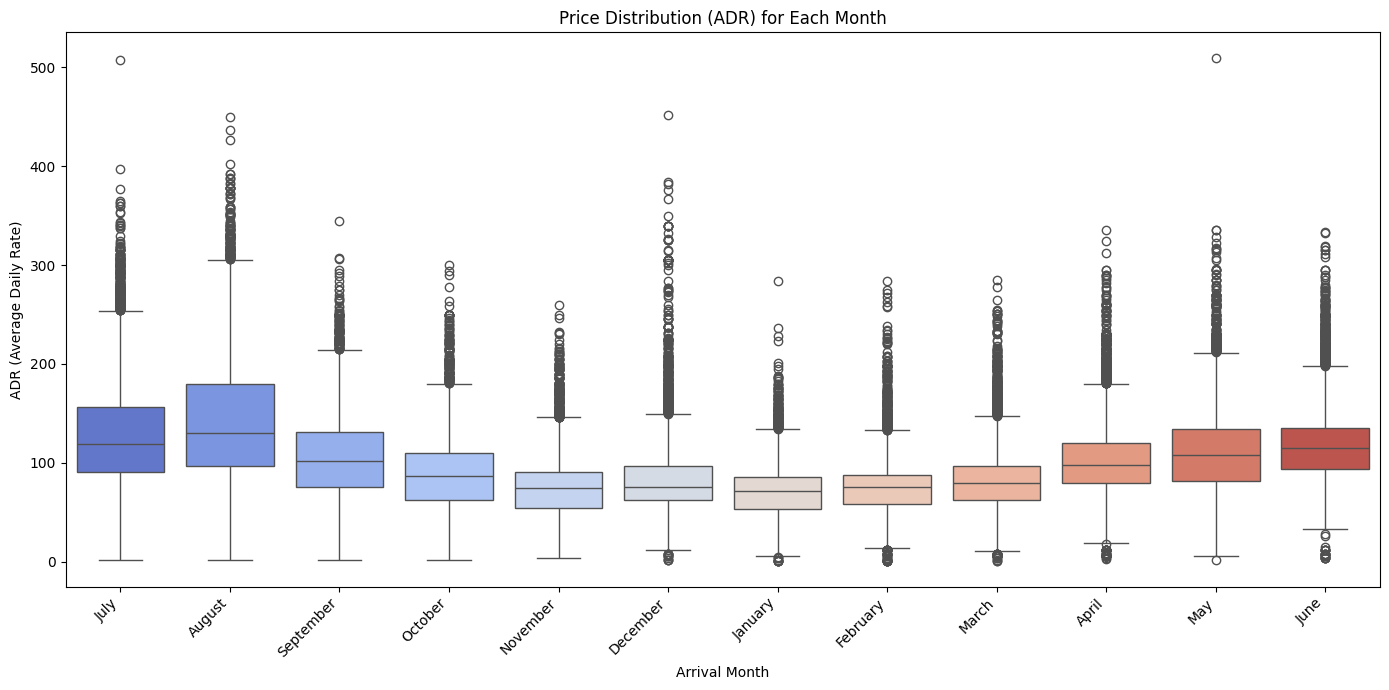

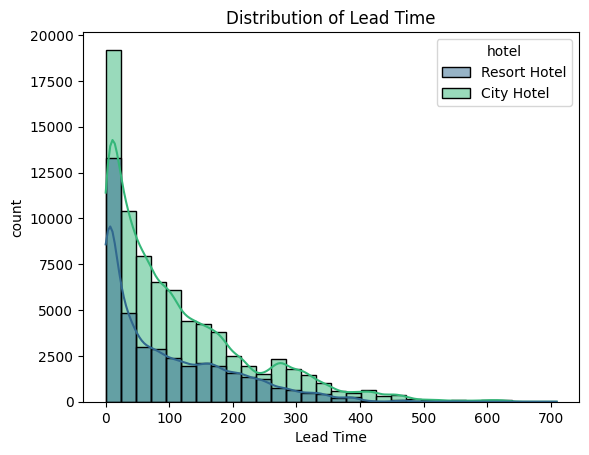

In [99]:

# Plot for Hotel Types
plt.figure(figsize=(8, 6))
sns.countplot(data=df_cleaned, x='hotel')
plt.title('Distribution of Hotel Types')
plt.xlabel('Hotel Type')
plt.ylabel('Count')
plt.show()

# Plot for Countries (improved readability)
plt.figure(figsize=(12, 7)) # Increased figure size

# Get top 10 countries by count
top_countries = df_cleaned['country'].value_counts().head(10).index

sns.countplot(data=df_cleaned, x='country', order=top_countries, hue='country', palette='viridis', legend=False) # Use order for better visualization, added hue and legend to address FutureWarning
plt.title('Top 10 Countries by Booking Count')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# Plot for price distribution for resort and city hotels
plt.figure(figsize=(10, 6))
sns.histplot(data=df_cleaned[df_cleaned['adr'] < 500], x='adr', hue='hotel', bins=30, kde=True)
plt.title('Price Distribution for Resort and City Hotels')
plt.xlabel('ADR (Average Daily Rate)')
plt.ylabel('Count')
plt.show()

# Plot for price distribution by month (using histogram)
plt.figure(figsize=(10, 6))
sns.histplot(data=df_cleaned[df_cleaned['adr'] < 500], x='adr', hue='arrival_date_month', bins=30, kde=True)
plt.title('Price Distribution by Month (Histogram)')
plt.xlabel('ADR (Average Daily Rate)')
plt.ylabel('Count')
plt.show()

# Plot for price distribution for each month (box plot)
plt.figure(figsize=(14, 7))
sns.boxplot(data = df_cleaned, x='arrival_date_month', y='adr', palette='coolwarm')
plt.title('Price Distribution (ADR) for Each Month')
plt.xlabel('Arrival Month')
plt.ylabel('ADR (Average Daily Rate)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot for the lead_time
sns.histplot(data=df_cleaned, x='lead_time',bins = 30, palette = 'viridis', hue = 'hotel',kde = True)
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time')
plt.ylabel('count')
plt.show()

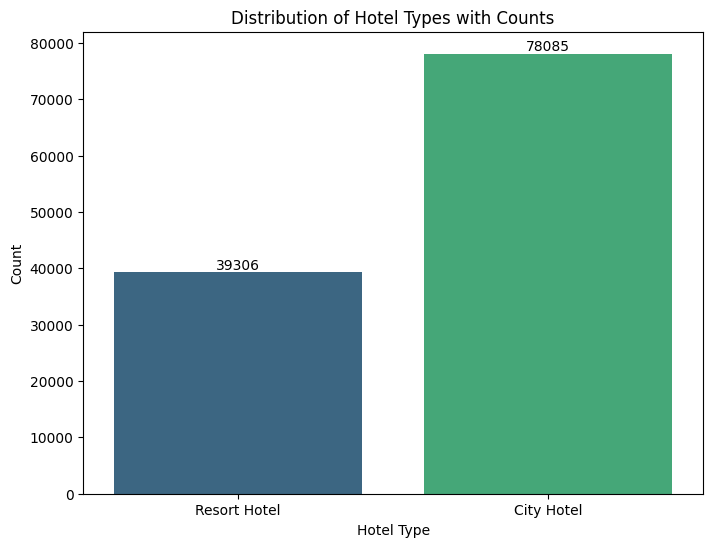

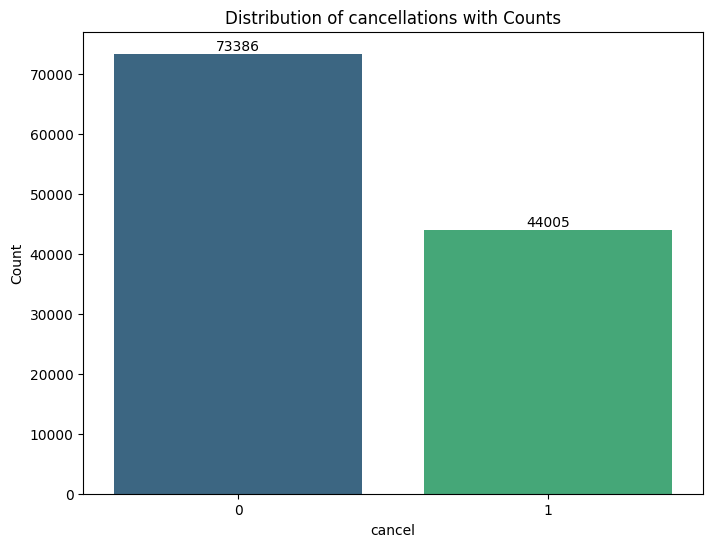

In [138]:
plt.figure(figsize=(8, 6))
# Capture the axes object
ax = sns.countplot(data=df_cleaned, x='hotel', palette='viridis', hue='hotel', legend=False)

# Iterate through the containers and add labels
for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Hotel Types with Counts')
plt.xlabel('Hotel Type')
plt.ylabel('Count')
plt.show()


plt.figure(figsize=(8, 6))
# Capture the axes object
ax = sns.countplot(data=df_cleaned, x='is_canceled', palette='viridis', hue='is_canceled', legend=False)

# Iterate through the containers and add labels
for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of cancellations with Counts')
plt.xlabel('cancel')
plt.ylabel('Count')
plt.show()

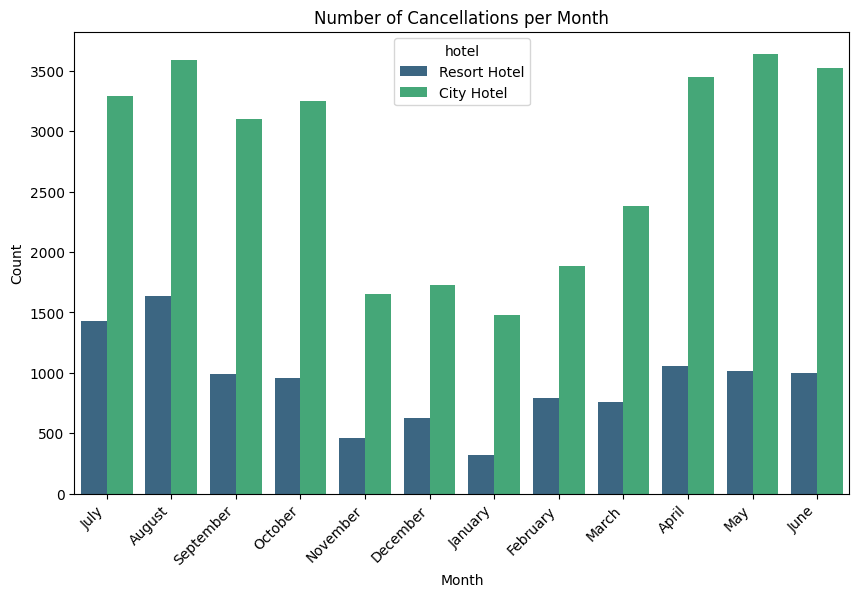

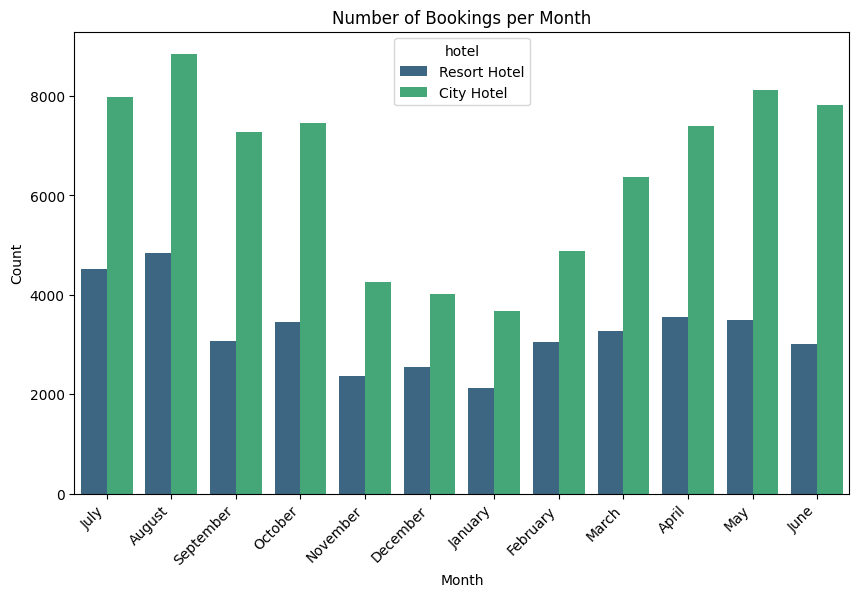

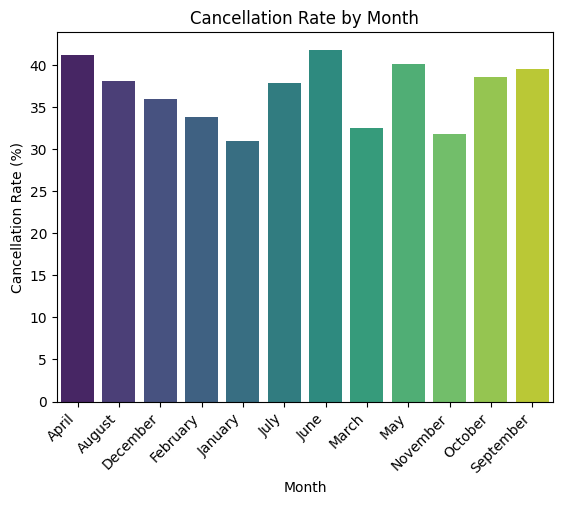

In [100]:
# Plot the number of cancellations per month
plt.figure(figsize=(10, 6))
sns.countplot(data=df_cleaned[df_cleaned['is_canceled']==1], x = 'arrival_date_month', hue = 'hotel', palette = 'viridis')
plt.title('Number of Cancellations per Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation = 45, ha = 'right')
plt.show()
# Plot the number of bookings per month
plt.figure(figsize=(10, 6))
sns.countplot(data=df_cleaned, x = 'arrival_date_month', hue = 'hotel', palette = 'viridis')
plt.title('Number of Bookings per Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation = 45, ha = 'right')
plt.show()

# Plot the cancelation rate by month
room_cancellations_by_month = df_cleaned.groupby('arrival_date_month')['is_canceled'].value_counts(normalize=True).unstack()
cancellation_rate_by_month = room_cancellations_by_month[1].fillna(0) * 100
sns.barplot(x=cancellation_rate_by_month.index, y=cancellation_rate_by_month.values, hue = cancellation_rate_by_month.index, palette='viridis')
plt.title('Cancellation Rate by Month')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.show()

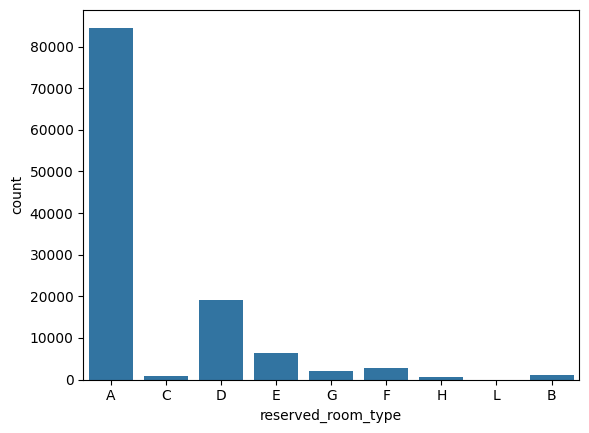

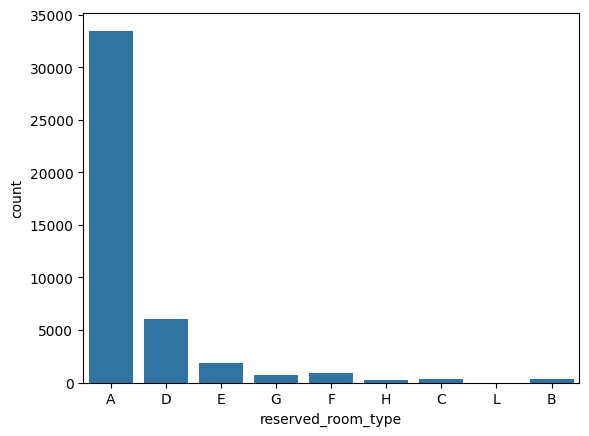

In [101]:
# room distribution
sns.countplot(data = df_cleaned, x = 'reserved_room_type')
plt.show()
# cancelation by room
sns.countplot(data = df_cleaned[df_cleaned['is_canceled']==1], x = 'reserved_room_type')
plt.show()


In [102]:
# Calculate cancellation rate by room type
room_cancellations = df_cleaned.groupby('reserved_room_type')['is_canceled'].value_counts(normalize=True).unstack()

# The '1' column represents cancellations, and '0' represents non-cancellations
# So, the cancellation rate is given by the '1' column (if it exists)
cancellation_rate_by_room = room_cancellations[1].fillna(0) * 100 # Convert to percentage and handle cases with no cancellations

print('Cancellation Rate by Room Type:')
print(cancellation_rate_by_room.sort_values(ascending=False))

Cancellation Rate by Room Type:
reserved_room_type
H    41.176471
A    39.592204
G    37.686939
C    33.515882
B    33.425926
L    33.333333
D    32.031373
F    30.913598
E    29.619819
Name: 1, dtype: float64


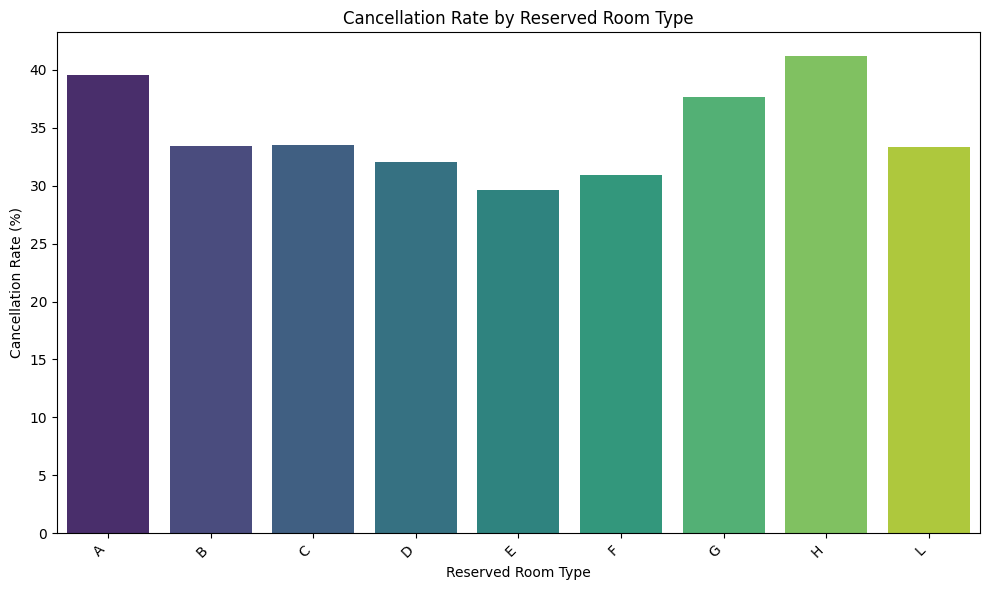

In [103]:
plt.figure(figsize=(10, 6))
sns.barplot(x=cancellation_rate_by_room.index, y=cancellation_rate_by_room.values, hue=cancellation_rate_by_room.index, palette='viridis', legend=False)
plt.title('Cancellation Rate by Reserved Room Type')
plt.xlabel('Reserved Room Type')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

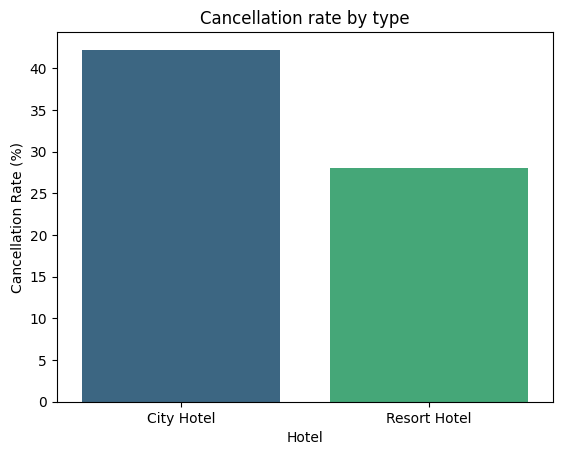

In [104]:
# percentage of each hotel that is cancellation
room_cancellations_by_hotel = df_cleaned.groupby('hotel')['is_canceled'].value_counts(normalize = True).unstack()
cancellation_rate_by_hotel = room_cancellations_by_hotel[1].fillna(0) *100
sns.barplot(x = cancellation_rate_by_hotel.index, y  = cancellation_rate_by_hotel.values, palette = 'viridis', hue = cancellation_rate_by_hotel.index)
plt.xlabel('Hotel')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation rate by type')
plt.show()


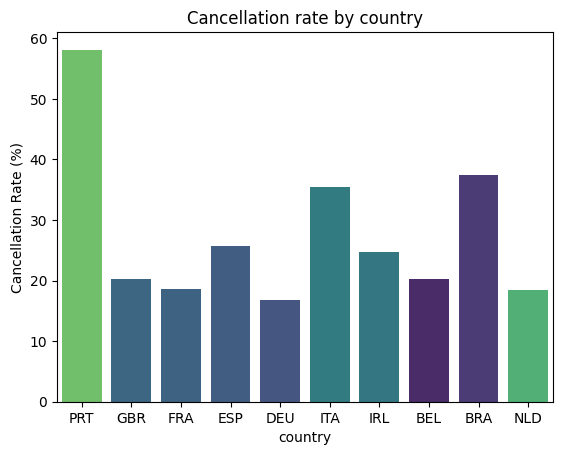

In [105]:
# percentage of each hotel that is cancellation
room_cancellations_by_country = df_cleaned.groupby('country')['is_canceled'].value_counts(normalize = True).unstack()
cancellation_rate_by_country = room_cancellations_by_country[1].fillna(0) *100
sns.barplot(x = cancellation_rate_by_country.index, y  = cancellation_rate_by_country.values, order = top_countries, palette = 'viridis', hue = cancellation_rate_by_country.index)
plt.xlabel('country')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation rate by country')
plt.show()

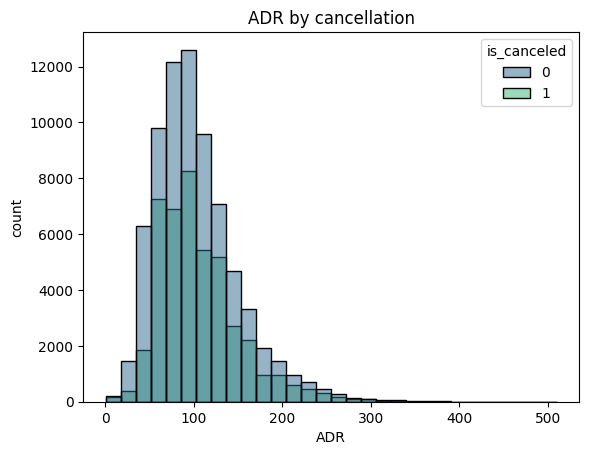

In [106]:
sns.histplot(data = df_cleaned, x = 'adr', bins = 30, hue = 'is_canceled', palette = 'viridis')
plt.xlabel('ADR')
plt.ylabel('count')
plt.title('ADR by cancellation')
plt.show()

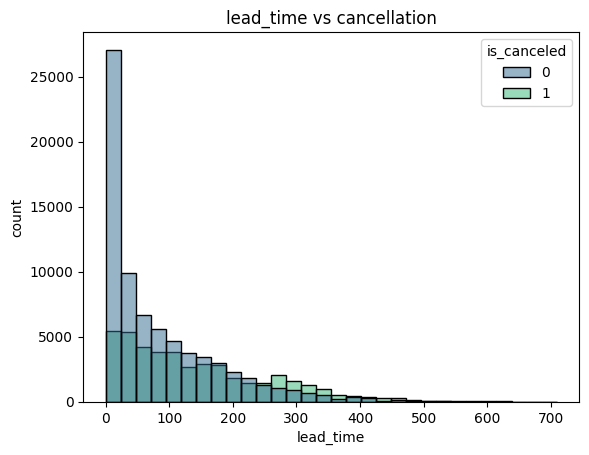

In [107]:
sns.histplot(data = df_cleaned, x = 'lead_time', bins = 30, hue = 'is_canceled', palette = 'viridis')
plt.xlabel('lead_time')
plt.ylabel('count')
plt.title('lead_time vs cancellation')
plt.show()

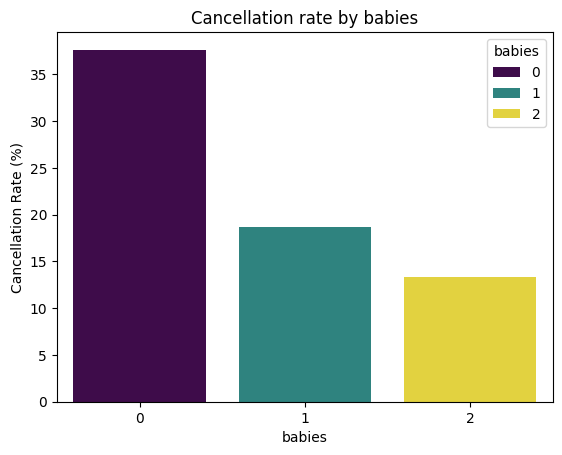

In [108]:
room_cancellations_by_babies = df_cleaned.groupby('babies')['is_canceled'].value_counts(normalize = True).unstack()
cancellation_rate_by_babies = room_cancellations_by_babies[1].fillna(0) *100
sns.barplot(x = cancellation_rate_by_babies.index, y = cancellation_rate_by_babies.values, palette = 'viridis', hue = cancellation_rate_by_babies.index)
plt.xlabel('babies')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation rate by babies')
plt.show()

Text(0.5, 1.0, 'Cancellation rate by adults')

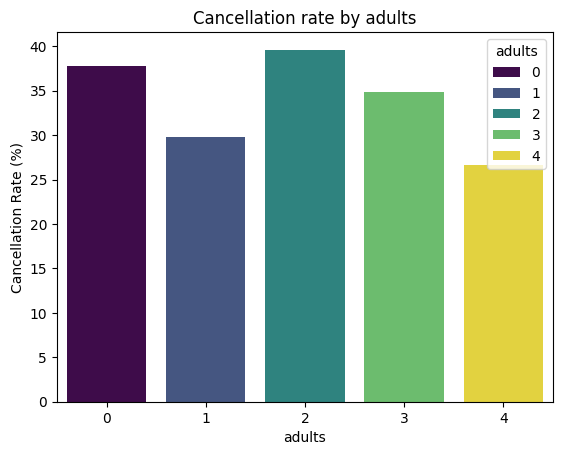

In [109]:
room_cancellations_by_adults = df_cleaned.groupby('adults')['is_canceled'].value_counts(normalize = True).unstack()
cancellation_rate_by_adults = room_cancellations_by_adults[1].fillna(0) *100
sns.barplot(x = cancellation_rate_by_adults.index, y = cancellation_rate_by_adults.values, palette = 'viridis', hue = cancellation_rate_by_adults.index)
plt.xlabel('adults')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation rate by adults')

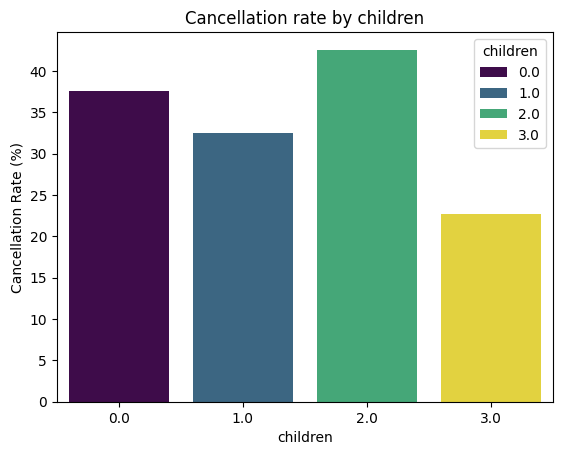

In [110]:
room_cancellations_by_children = df_cleaned.groupby('children')['is_canceled'].value_counts(normalize = True).unstack()
cancellation_rate_by_children = room_cancellations_by_children[1].fillna(0) *100
sns.barplot(x = cancellation_rate_by_children.index, y = cancellation_rate_by_children.values, palette = 'viridis', hue = cancellation_rate_by_children.index)
plt.xlabel('children')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation rate by children')
plt.show()

In [111]:
df[df['babies']>8].head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
46619,City Hotel,0,37,2016,January,3,12,0,2,2,...,No Deposit,9.0,NaN,0,Transient,84.45,0,1,Check-Out,2016-01-14
78656,City Hotel,0,11,2015,October,42,11,2,1,1,...,No Deposit,95.0,NaN,0,Transient-Party,95.00,0,0,Check-Out,2015-10-14


Factors important to determine cancellation:
1. country (some countries, e.g. PRT, have high cancellation rates)
2. type
3. room reservation type
4. month
5. adr
6. lead time
7. babies
8. previous cancellations


In [132]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
labels = ['not canceled', 'canceled']

We will first use the kNN classifier, using the features adr,

In [134]:
X = df_cleaned[['adr','lead_time','babies']]
y = df_cleaned['is_canceled'].values.ravel() # Use df_cleaned and flatten y to a 1D array

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Scale X_test as well

knn = KNeighborsClassifier(n_neighbors=51, weights = 'distance')
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled) # Predict using scaled test data
print(classification_report(y_test, y_pred, target_names = labels))

              precision    recall  f1-score   support

not canceled       0.79      0.87      0.83     14682
    canceled       0.74      0.61      0.67      8797

    accuracy                           0.77     23479
   macro avg       0.76      0.74      0.75     23479
weighted avg       0.77      0.77      0.77     23479



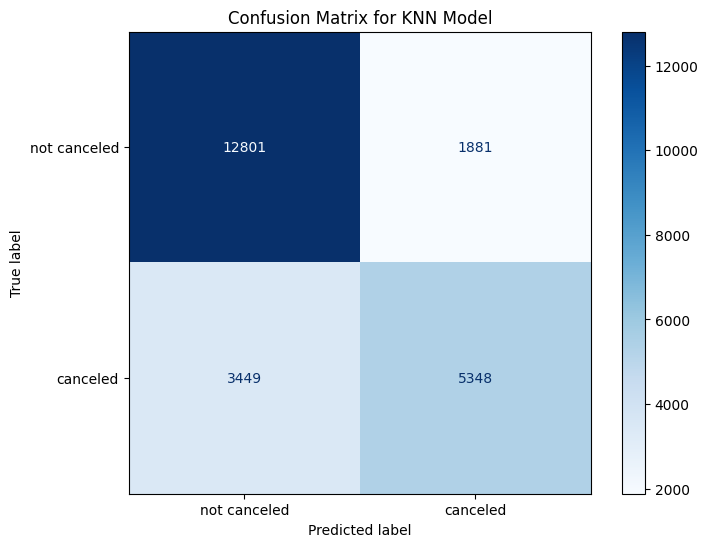

In [139]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix for KNN Model')
plt.show()

Now we will use logistic regression with the features
1. adr
2. babies
3. previous cancellations
4. lead time

In [130]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# Define features (X) and target (y)
X_lr = df_cleaned[['adr', 'babies', 'previous_cancellations', 'lead_time']]
y_lr = df_cleaned['is_canceled']

# Split data into training and testing sets
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

# Scale the features
scaler_lr = StandardScaler()
X_train_scaled_lr = scaler_lr.fit_transform(X_train_lr)
X_test_scaled_lr = scaler_lr.transform(X_test_lr)

# Initialize and train the Logistic Regression Classifier with class weighting
# 'balanced' mode automatically adjusts weights inversely proportional to class frequencies
log_reg_model = LogisticRegression(random_state=42, class_weight='balanced', solver='liblinear')
log_reg_model.fit(X_train_scaled_lr, y_train_lr)

# Make predictions on the test set
y_pred_lr = log_reg_model.predict(X_test_scaled_lr)

# Evaluate the model
print("Logistic Regression Classification Report:")
print(classification_report(y_test_lr, y_pred_lr, test_targets = labels))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.74      0.73     14682
           1       0.55      0.53      0.54      8797

    accuracy                           0.66     23479
   macro avg       0.64      0.63      0.64     23479
weighted avg       0.66      0.66      0.66     23479



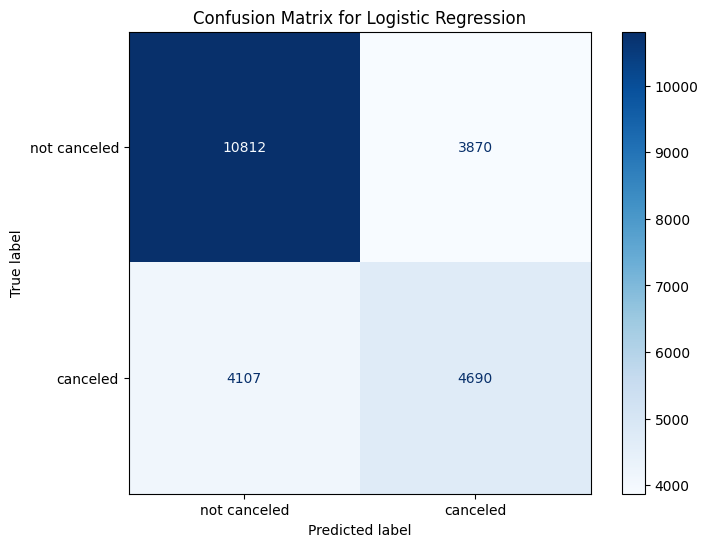

In [140]:
# Compute confusion matrix
cm = confusion_matrix(y_test_lr, y_pred_lr)

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [119]:
# Import CatBoostClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [123]:
X = df_cleaned[['country', 'hotel', 'reserved_room_type', 'arrival_date_month', 'adr', 'lead_time', 'babies']].copy()
y = df_cleaned['is_canceled']

# Fill NaN values in categorical features with 'Unknown' before splitting
# CatBoost requires categorical features to be strings or integers, not NaN floats
for col in ['country', 'hotel', 'reserved_room_type', 'arrival_date_month']:
    if col in X.columns:
        X[col] = X[col].fillna('Unknown').astype(str)


# Identify categorical features for CatBoost
categorical_features_indices = [X.columns.get_loc(col) for col in ['country', 'hotel', 'reserved_room_type', 'arrival_date_month']]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [126]:
# Initialize and train the CatBoost Classifier
cat_model = CatBoostClassifier(
    auto_class_weights = 'Balanced',
    iterations=100, # Number of boosting iterations
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss', # For binary classification
    eval_metric='Accuracy',
    random_seed=42,
    verbose=False # Suppress verbose output during training
)

cat_model.fit(X_train, y_train, cat_features=categorical_features_indices)

# Make predictions on the test set
y_pred_cat = cat_model.predict(X_test)

# Evaluate the model
print("CatBoost Classification Report:")
print(classification_report(y_test, y_pred_cat, target_names = labels))

CatBoost Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81     14682
           1       0.67      0.73      0.70      8797

    accuracy                           0.76     23479
   macro avg       0.75      0.76      0.75     23479
weighted avg       0.77      0.76      0.76     23479



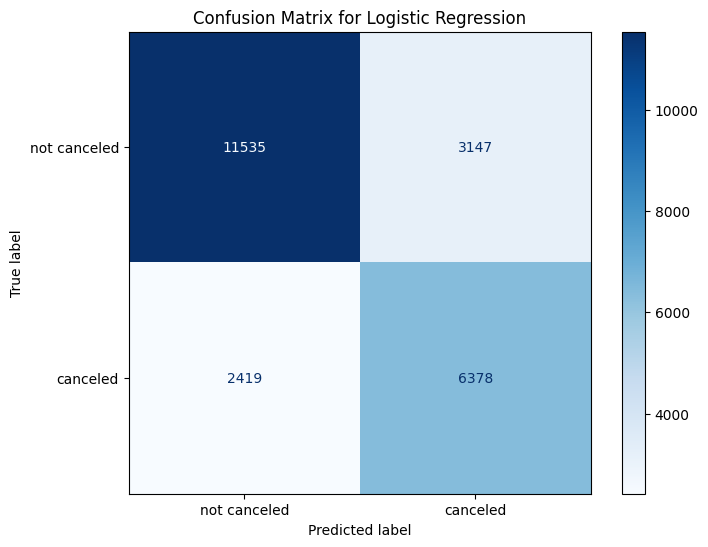

In [142]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_cat)

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix for Logistic Regression')
plt.show()